# Embeddings en Procesamiento del Lenguaje Natural

**Objetivo:** Entender cómo representar palabras como vectores numéricos para que los modelos de machine learning puedan procesarlas.

## Contenido
1. [¿Por qué necesitamos representaciones numéricas?](#1)
2. [One-Hot Encoding](#2)
3. [Word2Vec: Entrenamiento desde cero](#3)
4. [Word2Vec: Inferencia y análisis semántico](#4)
5. [Modelo pre-entrenado (GloVe vía Gensim)](#5)
6. [Sentence Embeddings y aplicaciones avanzadas](#6)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import pandas as pd
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import gensim
from gensim.models import Word2Vec
import gensim.downloader as api
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12
print(f'NumPy: {np.__version__}')
print(f'Gensim: {gensim.__version__}')

NumPy: 2.4.2
Gensim: 4.4.0


<a id='1'></a>
## 1. ¿Por qué necesitamos representaciones numéricas?

Los modelos de machine learning trabajan con números, no con texto. Necesitamos una forma de convertir palabras en vectores que:
- Sean comprensibles para un modelo
- Capturen el **significado** y las **relaciones** entre palabras
- Sean eficientes computacionalmente

Evolución histórica:

```
One-Hot  →  TF-IDF  →  Word2Vec  →  GloVe  →  FastText  →  BERT / Transformers
  1975         1972       2013        2014       2017           2018
  (sparse)    (sparse)  (dense)     (dense)    (dense)         (contextual)
```

<a id='2'></a>
## 2. One-Hot Encoding

La representación más simple: cada palabra es un vector con un `1` en su posición del vocabulario y `0` en el resto.

### 2.1 Construcción del vocabulario

In [2]:
# Corpus de ejemplo sobre aviación
corpus_raw = [
    "el avión despega del aeropuerto",
    "el piloto controla el avión",
    "el aeropuerto tiene muchas pistas",
    "el motor del avión falla en vuelo",
    "el piloto aterriza el avión en la pista",
    "el radar detecta el avión en vuelo",
    "el combustible alimenta el motor del avión",
]

# Tokenizar (separar en palabras y construir vocabulario)
tokens_corpus = [frase.lower().split() for frase in corpus_raw]
vocabulario = sorted(set(word for frase in tokens_corpus for word in frase))
vocab_size = len(vocabulario)
word2idx = {w: i for i, w in enumerate(vocabulario)}
idx2word = {i: w for w, i in word2idx.items()}

print(f'Tamaño del vocabulario: {vocab_size}')
print(f'Vocabulario: {vocabulario}')

Tamaño del vocabulario: 21
Vocabulario: ['aeropuerto', 'alimenta', 'aterriza', 'avión', 'combustible', 'controla', 'del', 'despega', 'detecta', 'el', 'en', 'falla', 'la', 'motor', 'muchas', 'piloto', 'pista', 'pistas', 'radar', 'tiene', 'vuelo']


### 2.2 Representación One-Hot

In [3]:
def one_hot(word, word2idx, vocab_size):
    vec = np.zeros(vocab_size, dtype=int)
    if word in word2idx:
        vec[word2idx[word]] = 1
    return vec

# Mostrar algunos vectores one-hot
palabras_ejemplo = ['avión', 'piloto', 'motor', 'pista']
print(f"{'Palabra':<12} {'Índice':<8} Vector one-hot")
print('-' * 60)
for palabra in palabras_ejemplo:
    vec = one_hot(palabra, word2idx, vocab_size)
    idx = word2idx[palabra]
    print(f"{palabra:<12} {idx:<8} {vec}")

Palabra      Índice   Vector one-hot
------------------------------------------------------------
avión        3        [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
piloto       15       [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
motor        13       [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
pista        16       [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


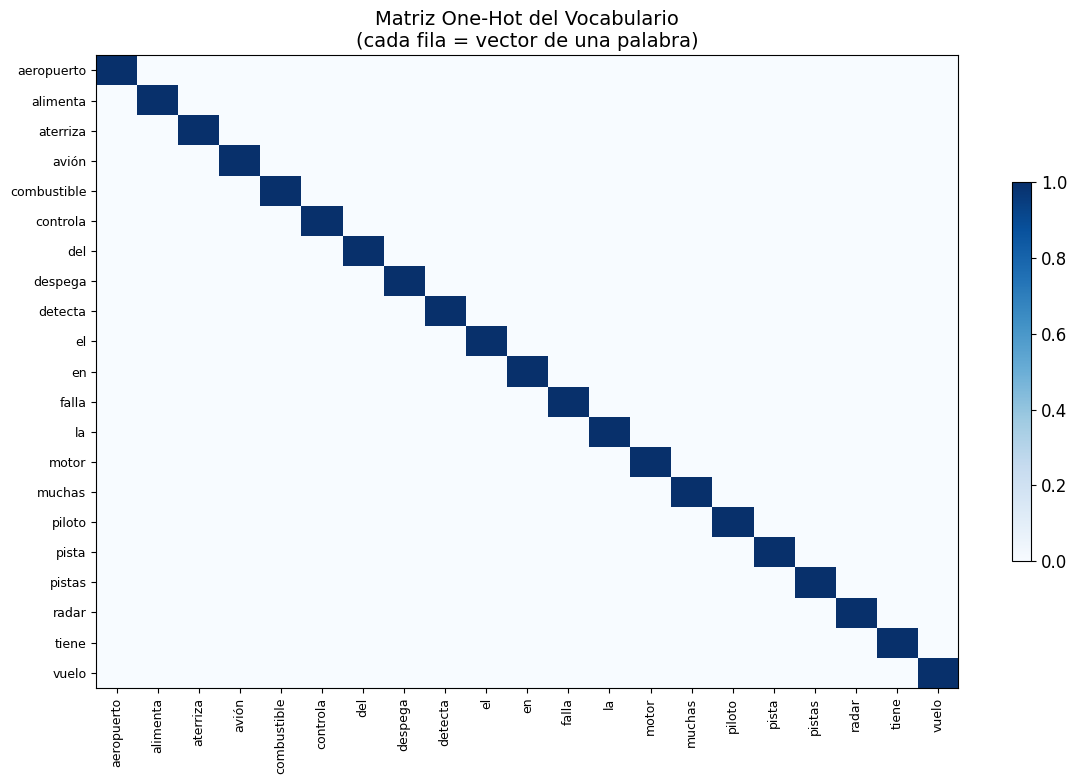

In [4]:
# Visualizar la matriz one-hot de todo el vocabulario
matrix_oh = np.eye(vocab_size, dtype=int)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(matrix_oh, cmap='Blues', aspect='auto')
ax.set_xticks(range(vocab_size))
ax.set_xticklabels(vocabulario, rotation=90, fontsize=9)
ax.set_yticks(range(vocab_size))
ax.set_yticklabels(vocabulario, fontsize=9)
ax.set_title('Matriz One-Hot del Vocabulario\n(cada fila = vector de una palabra)', fontsize=14)
plt.colorbar(im, ax=ax, shrink=0.6)
plt.tight_layout()
plt.show()

### 2.3 Similitud entre vectores one-hot

In [5]:
def similitud_coseno(v1, v2):
    norm = np.linalg.norm(v1) * np.linalg.norm(v2)
    return np.dot(v1, v2) / norm if norm > 0 else 0.0

# Con one-hot, dos palabras distintas siempre tienen similitud 0
pares = [('avión', 'avión'), ('avión', 'piloto'), ('motor', 'combustible')]
print('Similitud coseno entre vectores one-hot:')
for w1, w2 in pares:
    sim = similitud_coseno(one_hot(w1, word2idx, vocab_size),
                           one_hot(w2, word2idx, vocab_size))
    print(f"  sim('{w1}', '{w2}') = {sim:.4f}")

print()
print('PROBLEMA: one-hot no captura ninguna relación semántica entre palabras.')
print('"motor" y "combustible" son conceptualmente cercanos, pero su similitud es 0.')

Similitud coseno entre vectores one-hot:
  sim('avión', 'avión') = 1.0000
  sim('avión', 'piloto') = 0.0000
  sim('motor', 'combustible') = 0.0000

PROBLEMA: one-hot no captura ninguna relación semántica entre palabras.
"motor" y "combustible" son conceptualmente cercanos, pero su similitud es 0.


### 2.4 Limitaciones del One-Hot Encoding

| Problema | Descripción |
|----------|-------------|
| **Dimensionalidad** | El vector tiene tamaño = vocabulario (puede ser 100.000+) |
| **Esparsidad** | Solo 1 elemento es no-nulo → muy ineficiente en memoria |
| **Sin semántica** | Palabras sinónimas son ortogonales (sin relación) |
| **Sin contexto** | Ignora el orden y el contexto de las palabras |

**Solución:** Aprender representaciones **densas** que capturen semántica → **Word2Vec**

<a id='3'></a>
## 3. Word2Vec: Entrenamiento desde cero

Word2Vec (Mikolov et al., 2013) aprende vectores densos basándose en la hipótesis distribucional:
> *"Una palabra se caracteriza por la compañía que frecuenta"* — J.R. Firth (1957)

### Dos arquitecturas

```
CBOW (Continuous Bag of Words)        Skip-gram
──────────────────────────────        ──────────────────────────────
Entrada: palabras de contexto         Entrada: palabra central
Salida:  palabra central              Salida:  palabras de contexto

[despega] [del] [?] [del] [aeropuerto]  →  avión  →  [despega, del, del, aeropuerto]
```

### 3.1 Corpus ampliado para entrenamiento

In [6]:
# Corpus más amplio para entrenar Word2Vec
corpus_aviacion = [
    # Aeronaves
    "el avión comercial transporta pasajeros entre ciudades",
    "el avión militar vuela a gran altitud",
    "el helicóptero aterriza en la plataforma petrolífera",
    "el dron realiza misiones de reconocimiento",
    "el reactor propulsa el avión a alta velocidad",
    "el turbofán es el motor más eficiente para aviones comerciales",
    # Aeropuerto y operaciones
    "el aeropuerto tiene múltiples pistas de aterrizaje y despegue",
    "el piloto consulta la torre de control antes de despegar",
    "el copiloto asiste al piloto durante el vuelo",
    "el controlador aéreo guía al avión hacia la pista",
    "la pista está mojada y el piloto reduce la velocidad de aterrizaje",
    "el avión espera en la pista antes de despegar",
    # Sistemas
    "el motor consume combustible durante el vuelo",
    "el radar rastrea la posición de todos los aviones en el área",
    "el sistema de navegación usa GPS para guiar al avión",
    "el altímetro mide la altitud del avión sobre el nivel del mar",
    "el velocímetro indica la velocidad del avión en nudos",
    "el sistema de piloto automático controla el avión durante crucero",
    # Meteorología
    "las turbulencias afectan la estabilidad del vuelo",
    "el viento en contra reduce la velocidad del avión",
    "la niebla impide la visibilidad en el aeropuerto",
    "la tormenta obliga al piloto a cambiar la ruta del vuelo",
    # Espacio
    "el cohete propulsa el satélite a órbita terrestre",
    "el astronauta viaja en la nave espacial",
    "la nave espacial regresa a la atmósfera después de la misión",
    "el satélite orbita la tierra transmitiendo señales de navegación",
    "el motor del cohete quema combustible en la etapa de lanzamiento",
    # Mantenimiento
    "el mecánico revisa el motor antes de cada vuelo",
    "el ingeniero diseña el ala del avión para mayor eficiencia",
    "el combustible de aviación tiene alto poder calorífico",
    "el tren de aterrizaje soporta el peso del avión al aterrizar",
    # Comunicaciones
    "el piloto se comunica con la torre usando radio en frecuencias VHF",
    "el avión emite señales de transponder para identificación radar",
    "el sistema de alerta avisa al piloto de tráfico cercano",
]

# Tokenizar
sentences = [frase.lower().split() for frase in corpus_aviacion]
print(f'Frases en el corpus: {len(sentences)}')
print(f'Vocabulario aproximado: {len(set(w for s in sentences for w in s))} palabras')
print(f'\nEjemplo de frase tokenizada:')
print(f'  {sentences[0]}')

Frases en el corpus: 34
Vocabulario aproximado: 149 palabras

Ejemplo de frase tokenizada:
  ['el', 'avión', 'comercial', 'transporta', 'pasajeros', 'entre', 'ciudades']


### 3.2 Visualizar ventanas de contexto (Skip-gram)

In [7]:
def mostrar_ventanas(frase, ventana=2):
    words = frase.lower().split()
    print(f'Frase: "{frase}"')
    print(f'Ventana de contexto: {ventana}')
    print(f'\n{"Palabra central":<20} {"Contexto (pares de entrenamiento)"}')
    print('-' * 60)
    for i, word in enumerate(words):
        ctx = [words[j] for j in range(max(0, i-ventana), min(len(words), i+ventana+1)) if j != i]
        pares = [(word, c) for c in ctx]
        print(f'{word:<20} {pares}')

mostrar_ventanas("el piloto controla el avión", ventana=2)

Frase: "el piloto controla el avión"
Ventana de contexto: 2

Palabra central      Contexto (pares de entrenamiento)
------------------------------------------------------------
el                   [('el', 'piloto'), ('el', 'controla')]
piloto               [('piloto', 'el'), ('piloto', 'controla'), ('piloto', 'el')]
controla             [('controla', 'el'), ('controla', 'piloto'), ('controla', 'el'), ('controla', 'avión')]
el                   [('el', 'piloto'), ('el', 'controla'), ('el', 'avión')]
avión                [('avión', 'controla'), ('avión', 'el')]


### 3.3 Entrenamiento del modelo Word2Vec con Gensim

In [8]:
# Parámetros del modelo
VECTOR_SIZE = 50   # Dimensión del embedding
WINDOW = 3         # Tamaño de la ventana de contexto
MIN_COUNT = 1      # Frecuencia mínima para incluir una palabra
EPOCHS = 200       # Iteraciones de entrenamiento
SG = 1             # 1 = Skip-gram, 0 = CBOW

modelo_w2v = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=4,
    sg=SG,
    epochs=EPOCHS,
    seed=42
)

print(f'Modelo entrenado correctamente.')
print(f'Vocabulario del modelo: {len(modelo_w2v.wv)} palabras')
print(f'Dimensión de cada vector: {modelo_w2v.wv.vector_size}')

Modelo entrenado correctamente.
Vocabulario del modelo: 149 palabras
Dimensión de cada vector: 50


In [9]:
# Comparar one-hot vs Word2Vec para la misma palabra
palabra = 'avión'
vec_w2v = modelo_w2v.wv[palabra]

print(f'Representación de "{palabra}"')
print(f'\nOne-Hot ({vocab_size} dimensiones, {vocab_size-1} ceros):')
oh = one_hot(palabra, word2idx, vocab_size)
print(f'  {oh}')

print(f'\nWord2Vec ({VECTOR_SIZE} dimensiones, todos no-nulos):')
print(f'  {np.round(vec_w2v, 4)}')
print(f'  Norma del vector: {np.linalg.norm(vec_w2v):.4f}')

Representación de "avión"

One-Hot (21 dimensiones, 20 ceros):
  [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Word2Vec (50 dimensiones, todos no-nulos):
  [ 0.0116 -0.1248 -0.0291  0.0506 -0.0026  0.0998 -0.0208  0.4257 -0.2543
 -0.0827 -0.1012  0.1236  0.0131  0.1073  0.2153 -0.1467  0.03   -0.4753
 -0.1084 -0.1134 -0.1193  0.0471  0.1539  0.269   0.2697 -0.1118 -0.077
 -0.0817 -0.2721 -0.265   0.0875 -0.0787 -0.154   0.0114 -0.0028  0.0239
  0.1269 -0.507  -0.0905  0.0225  0.0975  0.1466  0.2095 -0.1627  0.1726
 -0.168  -0.0864  0.2411  0.2268  0.0779]
  Norma del vector: 1.2634


### 3.4 CBOW vs Skip-gram

In [10]:
# Comparar CBOW vs Skip-gram
modelo_cbow = Word2Vec(sentences=sentences, vector_size=50, window=3,
                       min_count=1, workers=4, sg=0, epochs=200, seed=42)
modelo_sg   = Word2Vec(sentences=sentences, vector_size=50, window=3,
                       min_count=1, workers=4, sg=1, epochs=200, seed=42)

palabra_test = 'piloto'
topn = 5

print(f'Palabras más similares a "{palabra_test}":' )
print(f'\n{"CBOW":<30} {"Skip-gram"}')
print('-' * 60)
sim_cbow = modelo_cbow.wv.most_similar(palabra_test, topn=topn)
sim_sg   = modelo_sg.wv.most_similar(palabra_test, topn=topn)
for (w1, s1), (w2, s2) in zip(sim_cbow, sim_sg):
    print(f'{w1:<20} {s1:.4f}    {w2:<20} {s2:.4f}')

Palabras más similares a "piloto":

CBOW                           Skip-gram
------------------------------------------------------------
sistema              0.9974    cercano              0.9638
torre                0.9968    alerta               0.9593
combustible          0.9965    consulta             0.9569
de                   0.9961    asiste               0.9548
con                  0.9961    copiloto             0.9494


<a id='4'></a>
## 4. Word2Vec: Inferencia y análisis semántico

### 4.1 Similitud semántica

In [11]:
wv = modelo_w2v.wv

pares = [
    ('avión', 'helicóptero'),
    ('avión', 'cohete'),
    ('piloto', 'copiloto'),
    ('motor', 'combustible'),
    ('radar', 'altímetro'),
    ('piloto', 'motor'),
    ('aeropuerto', 'pista'),
    ('tormenta', 'niebla'),
]

print(f'{"Par de palabras":<35} {"Similitud coseno"}')
print('-' * 55)
for w1, w2 in pares:
    try:
        sim = wv.similarity(w1, w2)
        print(f"({w1}, {w2}){'':>{30-len(w1)-len(w2)}}  {sim:.4f}")
    except KeyError as e:
        print(f"({w1}, {w2}) - palabra no encontrada: {e}")

Par de palabras                     Similitud coseno
-------------------------------------------------------
(avión, helicóptero)                0.8932
(avión, cohete)                     0.9054
(piloto, copiloto)                  0.9494
(motor, combustible)                0.8680
(radar, altímetro)                  0.8521
(piloto, motor)                     0.7723
(aeropuerto, pista)                 0.9282
(tormenta, niebla)                  0.9200


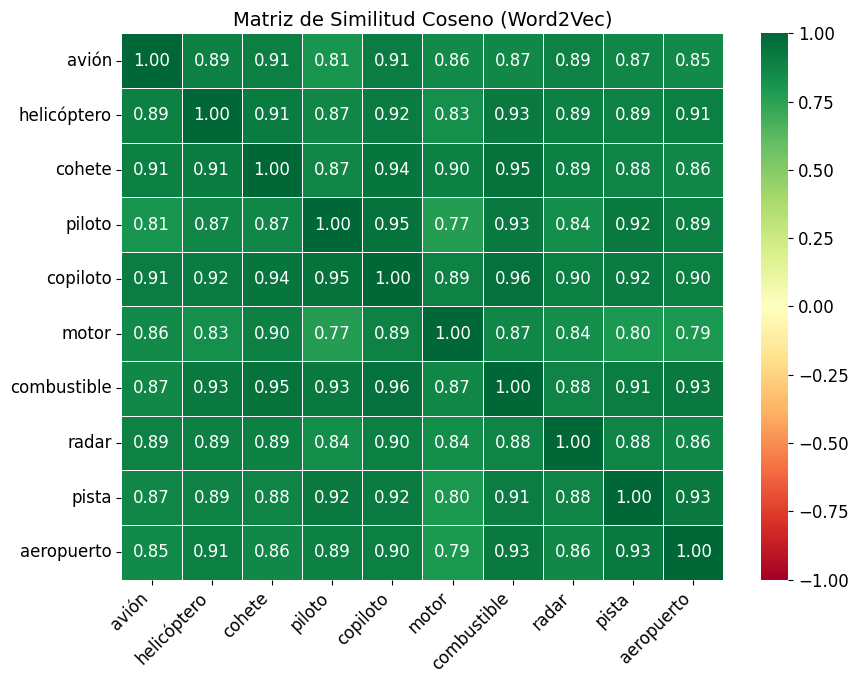

In [12]:
# Matriz de similitud
palabras_sel = ['avión', 'helicóptero', 'cohete', 'piloto', 'copiloto',
                'motor', 'combustible', 'radar', 'pista', 'aeropuerto']

palabras_sel = [p for p in palabras_sel if p in wv]
vecs = np.array([wv[p] for p in palabras_sel])
sim_matrix = cosine_similarity(vecs)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(len(palabras_sel), dtype=bool)
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=palabras_sel, yticklabels=palabras_sel,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Similitud Coseno (Word2Vec)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2 Analogías vectoriales

La propiedad más famosa de Word2Vec:

$$\vec{\text{rey}} - \vec{\text{hombre}} + \vec{\text{mujer}} \approx \vec{\text{reina}}$$

Esto se debe a que el espacio vectorial codifica **relaciones** de forma geométrica.

In [31]:
# Analogías en nuestro corpus (limitado por el tamaño del corpus)
# Con corpus pequeño la calidad es baja; con modelos grandes es espectacular

def analogia(modelo_wv, positivos, negativos, topn=3):
    """Calcula: positivos[0] - negativos[0] + positivos[1] ≈ ?"""
    try:
        resultado = modelo_wv.most_similar(positive=positivos, negative=negativos, topn=topn)
        return resultado
    except KeyError as e:
        return f'Palabra no encontrada: {e}'

# Analogías en nuestro dominio
tests_analogia = [
    (['cohete', 'orbita'], ['avión'],  'cohete → orbita como avión → ?'),
    (['altímetro', 'altitud'], ['velocímetro'], 'motor usa combustible como avión usa ?'),
    (['avión', 'pista'], ['cohete'],     'avión aterriza en pista, cohete en ?'),
]

for positivos, negativos, descripcion in tests_analogia:
    resultado = analogia(wv, positivos, negativos)
    print(f'Analogía: {descripcion}')
    print(f'  Resultado: {resultado}')
    print()

Analogía: cohete → orbita como avión → ?
  Resultado: [('transmitiendo', 0.9034788608551025), ('satélite', 0.8990876078605652), ('tierra', 0.8962690234184265)]

Analogía: motor usa combustible como avión usa ?
  Resultado: [('sobre', 0.9496960043907166), ('mide', 0.9366728067398071), ('nivel', 0.93443763256073)]

Analogía: avión aterriza en pista, cohete en ?
  Resultado: [('reduce', 0.8980446457862854), ('mojada', 0.8957932591438293), ('guía', 0.8945292830467224)]



### 4.3 Visualización con PCA

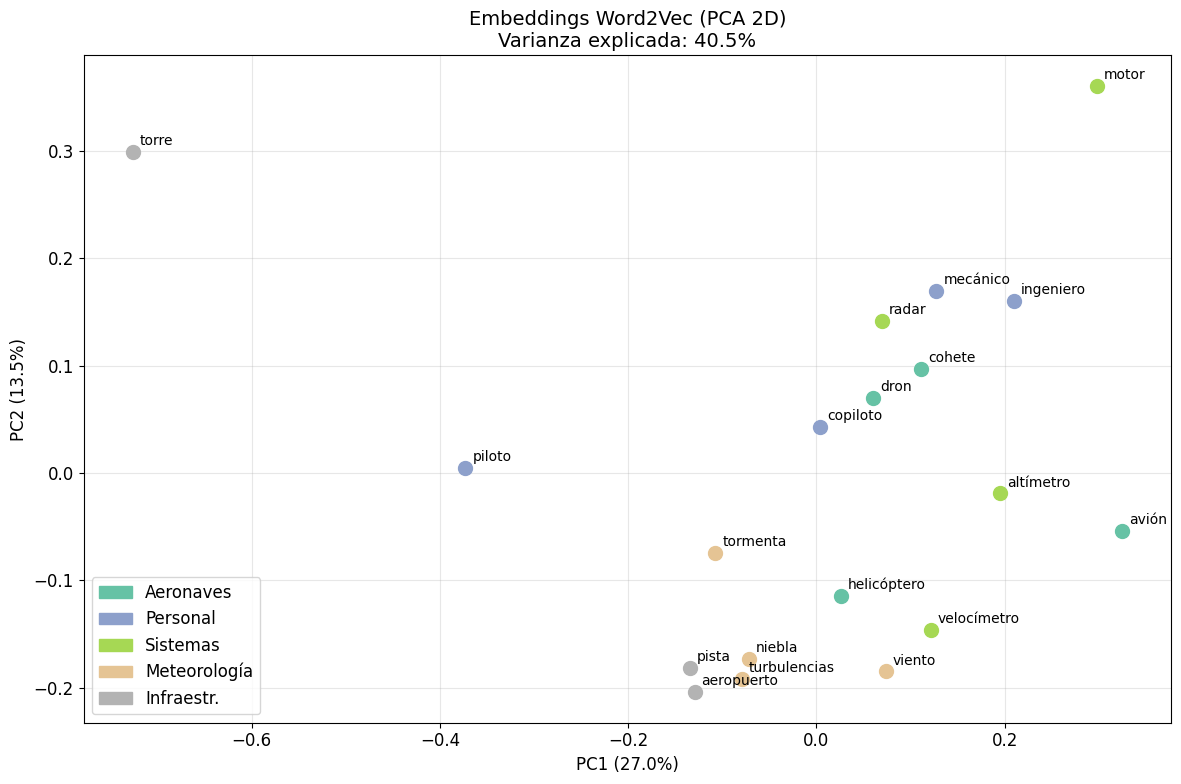

Varianza total explicada por las 2 primeras componentes: 40.5%


In [14]:
# Seleccionar palabras representativas por categorías
categorias = {
    'Aeronaves':    ['avión', 'helicóptero', 'dron', 'cohete'],
    'Personal':     ['piloto', 'copiloto', 'mecánico', 'ingeniero'],
    'Sistemas':     ['motor', 'radar', 'altímetro', 'velocímetro'],
    'Meteorología': ['tormenta', 'niebla', 'viento', 'turbulencias'],
    'Infraestr.':   ['aeropuerto', 'pista', 'torre'],
}

palabras_viz = []
etiquetas_cat = []
for cat, words in categorias.items():
    for w in words:
        if w in wv:
            palabras_viz.append(w)
            etiquetas_cat.append(cat)

vectores_viz = np.array([wv[w] for w in palabras_viz])

# Reducir a 2D con PCA
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(vectores_viz)

# Graficar
cats_unicas = list(categorias.keys())
colores = plt.cm.Set2(np.linspace(0, 1, len(cats_unicas)))
cat2color = dict(zip(cats_unicas, colores))

fig, ax = plt.subplots(figsize=(12, 8))
for i, (palabra, cat) in enumerate(zip(palabras_viz, etiquetas_cat)):
    x, y = coords_pca[i]
    ax.scatter(x, y, color=cat2color[cat], s=100, zorder=3)
    ax.annotate(palabra, (x, y), textcoords='offset points',
                xytext=(5, 5), fontsize=10)

# Leyenda
from matplotlib.patches import Patch
leyenda = [Patch(color=cat2color[c], label=c) for c in cats_unicas]
ax.legend(handles=leyenda, loc='best')
ax.set_title(f'Embeddings Word2Vec (PCA 2D)\nVarianza explicada: {pca.explained_variance_ratio_.sum():.1%}', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Varianza total explicada por las 2 primeras componentes: {pca.explained_variance_ratio_.sum():.1%}')

### 4.4 Visualización con t-SNE

t-SNE (t-distributed Stochastic Neighbor Embedding) preserva mejor las **estructuras locales** que PCA.

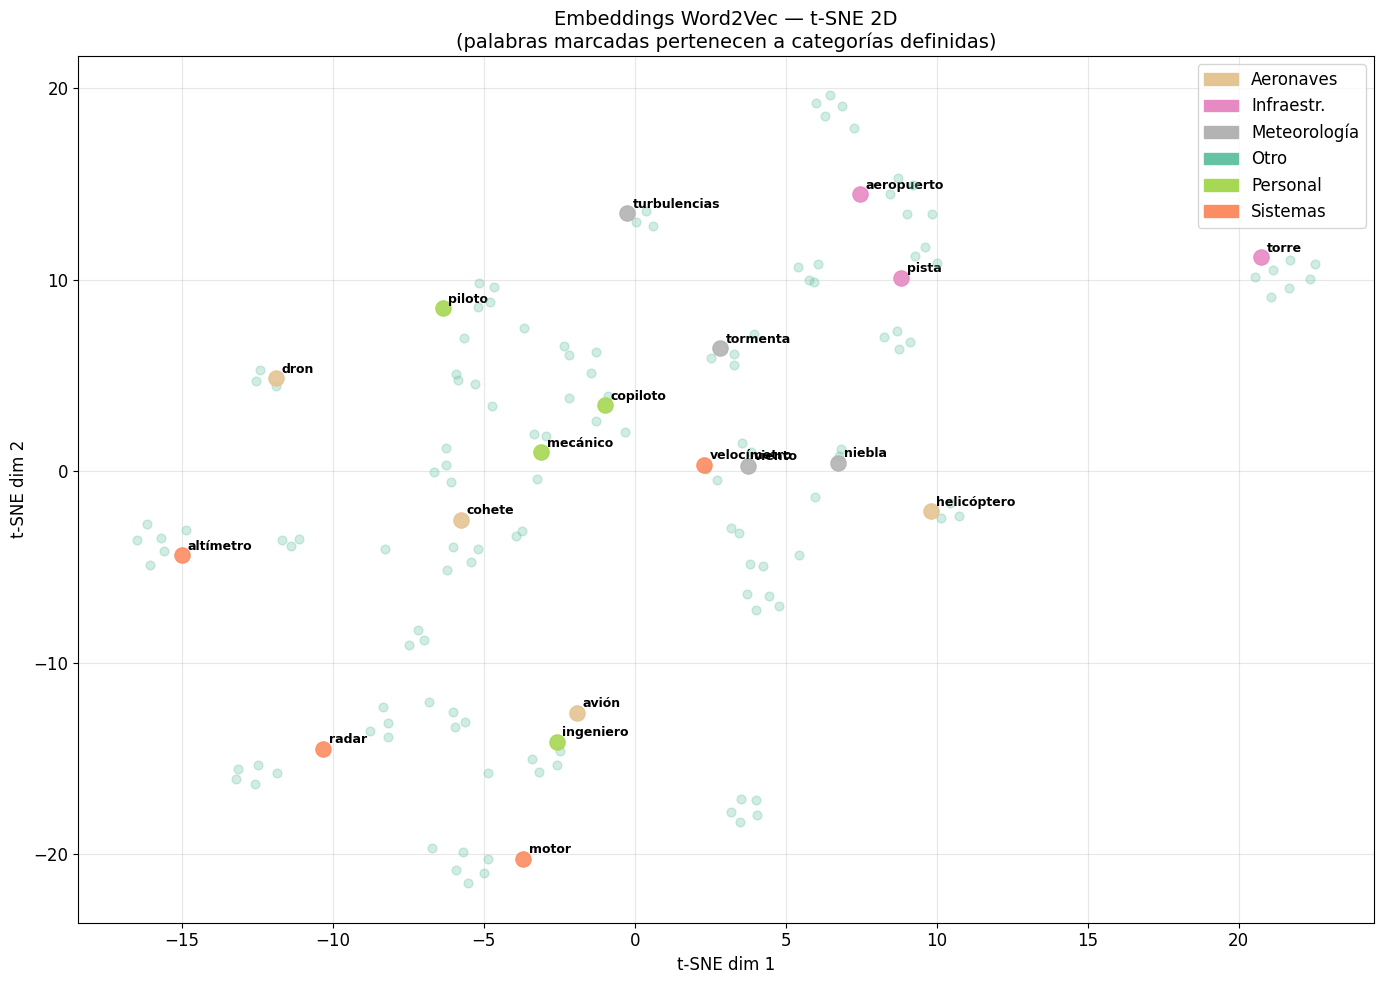

In [15]:
# Usar todas las palabras del vocabulario para t-SNE
todas_palabras = list(wv.key_to_index.keys())
todos_vectores = np.array([wv[w] for w in todas_palabras])

# t-SNE requiere al menos n_components + 1 muestras y perplexity < n_samples
n = len(todas_palabras)
perp = min(15, n - 1)

tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
coords_tsne = tsne.fit_transform(todos_vectores)

# Asignar categoría a cada palabra ("otro" si no está en categorías)
word2cat = {}
for cat, words in categorias.items():
    for w in words:
        word2cat[w] = cat

cats_all = [word2cat.get(w, 'Otro') for w in todas_palabras]
cats_unicas_all = list(set(cats_all))
colores_all = plt.cm.Set2(np.linspace(0, 1, len(cats_unicas_all)))
cat2color_all = dict(zip(cats_unicas_all, colores_all))

fig, ax = plt.subplots(figsize=(14, 10))
for i, (palabra, cat) in enumerate(zip(todas_palabras, cats_all)):
    x, y = coords_tsne[i]
    alpha = 0.9 if cat != 'Otro' else 0.3
    size  = 120 if cat != 'Otro' else 40
    ax.scatter(x, y, color=cat2color_all[cat], s=size, alpha=alpha, zorder=3)
    if cat != 'Otro':
        ax.annotate(palabra, (x, y), textcoords='offset points',
                    xytext=(4, 4), fontsize=9, fontweight='bold')

leyenda = [Patch(color=cat2color_all[c], label=c) for c in sorted(cats_unicas_all)]
ax.legend(handles=leyenda, loc='best')
ax.set_title('Embeddings Word2Vec — t-SNE 2D\n(palabras marcadas pertenecen a categorías definidas)', fontsize=14)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Operaciones vectoriales: aritmética semántica

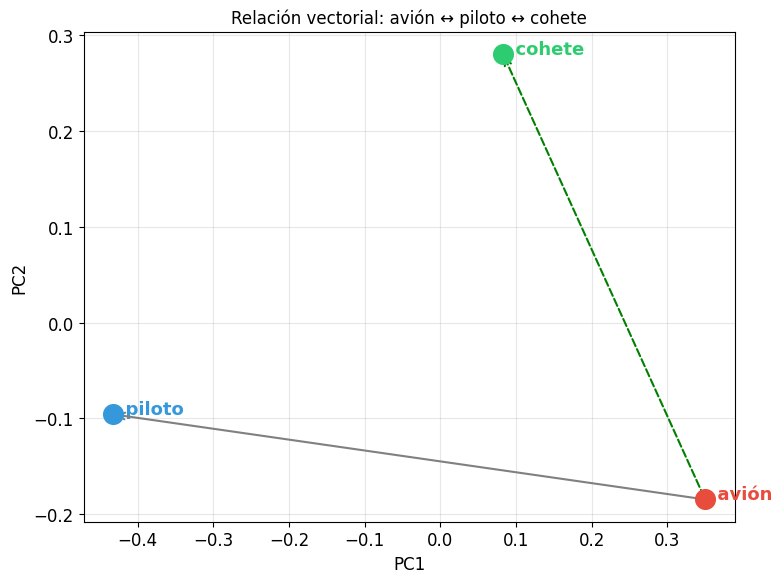

In [16]:
# Visualizar la aritmética vectorial
# Ejemplo: avión + pista (pares relacionados)

def plot_vectores_aritmetica(wv, palabra_a, palabra_b, palabra_resultado, n_componentes=2):
    words = [palabra_a, palabra_b, palabra_resultado]
    words_ok = [w for w in words if w in wv]
    if len(words_ok) < 2:
        print('No hay suficientes palabras en el vocabulario.')
        return

    vecs = np.array([wv[w] for w in words_ok])
    pca2 = PCA(n_components=2, random_state=42)
    coords = pca2.fit_transform(vecs)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for i, (w, (x, y)) in enumerate(zip(words_ok, coords)):
        ax.scatter(x, y, s=200, color=colors[i], zorder=4)
        ax.annotate(f'  {w}', (x, y), fontsize=13, fontweight='bold', color=colors[i])

    if len(words_ok) >= 2:
        ax.annotate('', xy=coords[1], xytext=coords[0],
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    if len(words_ok) >= 3:
        ax.annotate('', xy=coords[2], xytext=coords[0],
                    arrowprops=dict(arrowstyle='->', color='green', lw=1.5, linestyle='--'))

    ax.set_title(f'Relación vectorial: {" ↔ ".join(words_ok)}', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    plt.tight_layout()
    plt.show()

plot_vectores_aritmetica(wv, 'avión', 'piloto', 'cohete')

<a id='5'></a>
## 5. Modelo Pre-entrenado: GloVe vía Gensim

Los modelos pre-entrenados están entrenados en **miles de millones** de palabras. Capturan semántica general del lenguaje.

Usaremos `glove-wiki-gigaword-50`: entrenado en Wikipedia + Gigaword, vectores de 50 dimensiones (~66 MB).

> **GloVe** (Global Vectors, Pennington et al. 2014) aprende vectores minimizando diferencias entre el log de co-ocurrencias globales y el producto escalar de vectores.

In [17]:
print('Descargando modelo pre-entrenado GloVe (Wikipedia + Gigaword, 50d)...')
print('Primera vez: ~66 MB, quedará en caché en ~/.cache/gensim-data/')
print()

glove = api.load('glove-wiki-gigaword-50')

print(f'Modelo cargado.')
print(f'Vocabulario: {len(glove):,} palabras')
print(f'Dimensión:   {glove.vector_size}')

Descargando modelo pre-entrenado GloVe (Wikipedia + Gigaword, 50d)...
Primera vez: ~66 MB, quedará en caché en ~/.cache/gensim-data/

Modelo cargado.
Vocabulario: 400,000 palabras
Dimensión:   50


### 5.1 Tareas clásicas de PLN: similitud y palabras cercanas

In [18]:
# Palabras más cercanas a conceptos de aviación
queries = ['airplane', 'pilot', 'airport', 'radar', 'turbulence', 'spacecraft']

for query in queries:
    similares = glove.most_similar(query, topn=6)
    words_sim = ', '.join([f'{w} ({s:.2f})' for w, s in similares])
    print(f'{query:<15} → {words_sim}')

airplane        → plane (0.86), jet (0.86), airplanes (0.86), jetliner (0.83), aircraft (0.82), planes (0.81)
pilot           → crew (0.85), pilots (0.81), flight (0.79), helicopter (0.78), plane (0.76), aircraft (0.76)
airport         → port (0.81), heathrow (0.78), airports (0.78), metro (0.73), transit (0.73), flights (0.73)
radar           → radars (0.88), infrared (0.82), satellites (0.79), satellite (0.77), sonar (0.76), sensors (0.75)
turbulence      → downturn (0.76), upheaval (0.74), fluctuations (0.73), upheavals (0.73), uncertainty (0.73), plunge (0.73)
spacecraft      → orbit (0.90), orbiter (0.89), spaceship (0.85), soyuz (0.84), orbiting (0.84), satellites (0.84)


### 5.2 Analogías con el modelo pre-entrenado

$$\vec{\text{king}} - \vec{\text{man}} + \vec{\text{woman}} \approx \vec{\text{queen}}$$

In [ ]:
analogias = [
    # (positivos, negativos, descripción)
    (['king', 'woman'],  ['man'],       'king - man + woman = ?'),
    (['paris', 'germany'], ['france'],  'paris - france + germany = ?'),
    (['airplane', 'water'], ['air'],    'airplane - air + water = ?'),
    (['pilot', 'ship'],  ['airplane'],  'pilot - airplane + ship = ?'),
    (['fast', 'slower'], ['slow'],      'fast - slow + slower = ?'),
    (['madrid', 'france'], ['spain'],   'madrid - spain + france = ?'),
    (['walking', 'swam'], ['swimming'], 'walking - swimming + swam = ?'),
]

print(f'{"Analogía":<40} {"Resultado (top 3)"}')
print('=' * 80)
for pos, neg, desc in analogias:
    resultado = glove.most_similar(positive=pos, negative=neg, topn=3)
    res_str = ', '.join([f'{w}({s:.2f})' for w, s in resultado])
    print(f'{desc:<40} {res_str}')

Analogía                                 Resultado (top 3)
king - man + woman = ?                   queen(0.85), throne(0.77), prince(0.76)
paris - france + germany = ?             berlin(0.92), frankfurt(0.82), vienna(0.82)
airplane - sky + water = ?               garbage(0.72), floating(0.70), debris(0.69)
pilot - airplane + ship = ?              navy(0.80), vessel(0.78), naval(0.75)
fast - slow + slower = ?                 faster(0.82), fastest(0.80), pace(0.78)
madrid - spain + france = ?              paris(0.82), marseille(0.81), lyon(0.80)
walking - swimming + swam = ?            wandered(0.77), walked(0.73), hopped(0.70)


### 5.3 Odd-one-out: intruso semántico

In [20]:
grupos = [
    ['airplane', 'helicopter', 'drone', 'submarine'],
    ['pilot', 'copilot', 'engineer', 'runway'],
    ['paris', 'madrid', 'berlin', 'airplane'],
    ['turbulence', 'fog', 'storm', 'cockpit'],
    ['engine', 'fuel', 'radar', 'breakfast'],
]

print('Detección de intruso (odd-one-out):')
print('=' * 50)
for grupo in grupos:
    intruso = glove.doesnt_match(grupo)
    print(f'  {grupo} → intruso: "{intruso}"')

Detección de intruso (odd-one-out):
  ['airplane', 'helicopter', 'drone', 'submarine'] → intruso: "drone"
  ['pilot', 'copilot', 'engineer', 'runway'] → intruso: "runway"
  ['paris', 'madrid', 'berlin', 'airplane'] → intruso: "airplane"
  ['turbulence', 'fog', 'storm', 'cockpit'] → intruso: "cockpit"
  ['engine', 'fuel', 'radar', 'breakfast'] → intruso: "breakfast"


### 5.4 Visualización PCA del modelo pre-entrenado

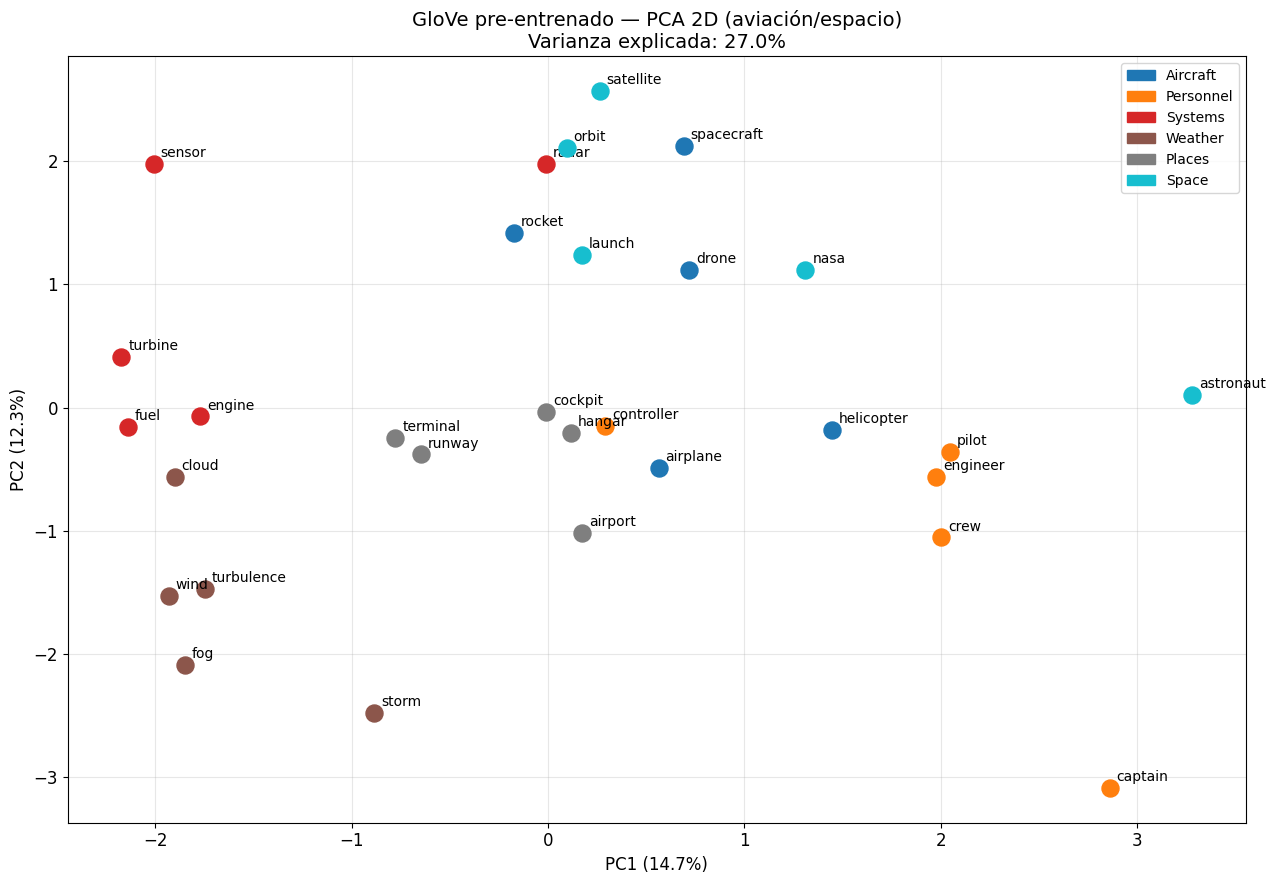

In [21]:
categorias_glove = {
    'Aircraft':    ['airplane', 'helicopter', 'drone', 'rocket', 'spacecraft'],
    'Personnel':   ['pilot', 'captain', 'engineer', 'controller', 'crew'],
    'Systems':     ['engine', 'radar', 'fuel', 'sensor', 'turbine'],
    'Weather':     ['turbulence', 'fog', 'storm', 'wind', 'cloud'],
    'Places':      ['airport', 'runway', 'hangar', 'cockpit', 'terminal'],
    'Space':       ['orbit', 'satellite', 'nasa', 'launch', 'astronaut'],
}

palabras_g, etiquetas_g = [], []
for cat, words in categorias_glove.items():
    for w in words:
        if w in glove:
            palabras_g.append(w)
            etiquetas_g.append(cat)

vectores_g = np.array([glove[w] for w in palabras_g])
pca_g = PCA(n_components=2, random_state=42)
coords_g = pca_g.fit_transform(vectores_g)

cats_g = list(categorias_glove.keys())
colors_g = plt.cm.tab10(np.linspace(0, 0.9, len(cats_g)))
c2col = dict(zip(cats_g, colors_g))

fig, ax = plt.subplots(figsize=(13, 9))
for i, (word, cat) in enumerate(zip(palabras_g, etiquetas_g)):
    x, y = coords_g[i]
    ax.scatter(x, y, color=c2col[cat], s=150, zorder=3)
    ax.annotate(word, (x, y), textcoords='offset points', xytext=(5, 5), fontsize=10)

leyenda_g = [Patch(color=c2col[c], label=c) for c in cats_g]
ax.legend(handles=leyenda_g, loc='best', fontsize=10)
ax.set_title(f'GloVe pre-entrenado — PCA 2D (aviación/espacio)\n'
             f'Varianza explicada: {pca_g.explained_variance_ratio_.sum():.1%}', fontsize=14)
ax.set_xlabel(f'PC1 ({pca_g.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_g.explained_variance_ratio_[1]:.1%})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Comparación: modelo propio vs pre-entrenado

In [22]:
# Traducción de las palabras del corpus propio para comparar
traduccion = {
    'avión': 'airplane', 'piloto': 'pilot', 'motor': 'engine',
    'radar': 'radar', 'pista': 'runway', 'aeropuerto': 'airport',
    'combustible': 'fuel', 'cohete': 'rocket', 'helicóptero': 'helicopter',
    'tormenta': 'storm', 'niebla': 'fog', 'turbulencias': 'turbulence',
}

print('Comparación de similitudes (modelo propio vs GloVe pre-entrenado):')
print(f'{"Par":<35} {"Propio":>10} {"GloVe":>10}')
print('-' * 58)

pares_comp = [
    ('avión', 'helicóptero'),
    ('piloto', 'copiloto'),
    ('motor', 'combustible'),
    ('tormenta', 'niebla'),
    ('radar', 'altímetro'),
    ('aeropuerto', 'pista'),
]

for w1_es, w2_es in pares_comp:
    w1_en = traduccion.get(w1_es, w1_es)
    w2_en = traduccion.get(w2_es, w2_es)
    sim_propio = wv.similarity(w1_es, w2_es) if (w1_es in wv and w2_es in wv) else float('nan')
    sim_glove  = glove.similarity(w1_en, w2_en) if (w1_en in glove and w2_en in glove) else float('nan')
    par_str = f'({w1_es}/{w1_en}, {w2_es}/{w2_en})'
    print(f'{par_str:<35} {sim_propio:>10.4f} {sim_glove:>10.4f}')

Comparación de similitudes (modelo propio vs GloVe pre-entrenado):
Par                                     Propio      GloVe
----------------------------------------------------------
(avión/airplane, helicóptero/helicopter)     0.8932     0.7298
(piloto/pilot, copiloto/copiloto)       0.9494        nan
(motor/engine, combustible/fuel)        0.8680     0.6453
(tormenta/storm, niebla/fog)            0.9200     0.6581
(radar/radar, altímetro/altímetro)      0.8521        nan
(aeropuerto/airport, pista/runway)      0.9282     0.6588


<a id='6'></a>
## 6. Sentence Embeddings y aplicaciones avanzadas

### 6.1 Sentence Embeddings: representar frases enteras

Un método simple: **promediar** los vectores de las palabras de la frase.

$$\vec{s} = \frac{1}{|s|} \sum_{w \in s} \vec{w}$$

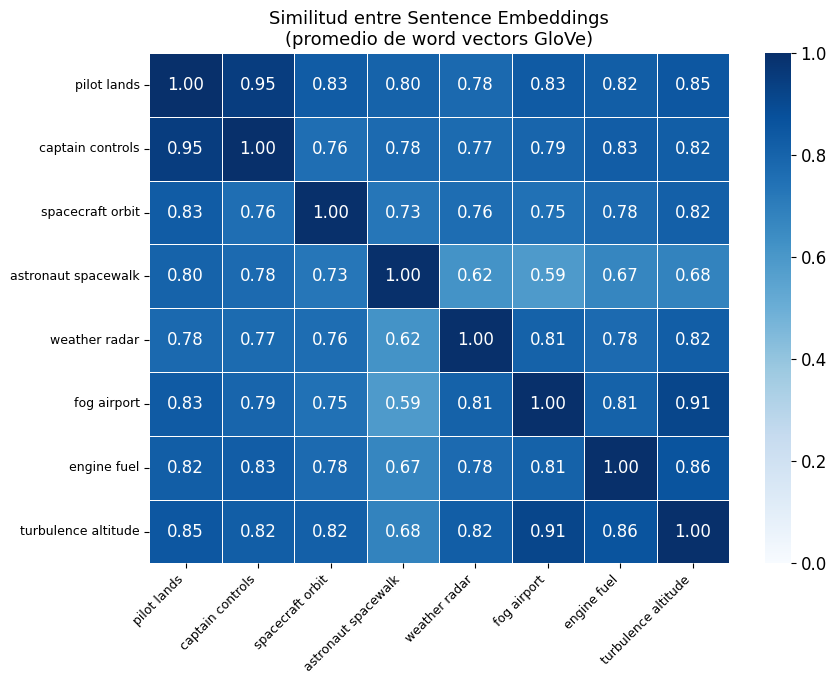

In [23]:
def sentence_embedding(sentence, model_wv, lang='en'):
    words = sentence.lower().split()
    vecs = [model_wv[w] for w in words if w in model_wv]
    return np.mean(vecs, axis=0) if vecs else None

frases = [
    "the pilot lands the airplane on the runway",
    "the captain controls the aircraft during flight",
    "the spacecraft enters orbit around earth",
    "the astronaut performs a spacewalk",
    "the weather radar detects storm systems",
    "fog reduces visibility at the airport",
    "the engine consumes fuel during takeoff",
    "turbulence shakes the airplane at high altitude",
]

embeddings_frases = np.array([sentence_embedding(f, glove) for f in frases])
sim_frases = cosine_similarity(embeddings_frases)

# Etiquetas cortas para la visualización
etiquetas_cortas = [
    'pilot lands', 'captain controls', 'spacecraft orbit',
    'astronaut spacewalk', 'weather radar', 'fog airport',
    'engine fuel', 'turbulence altitude'
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_frases, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas,
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Similitud entre Sentence Embeddings\n(promedio de word vectors GloVe)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### 6.2 Clustering de palabras

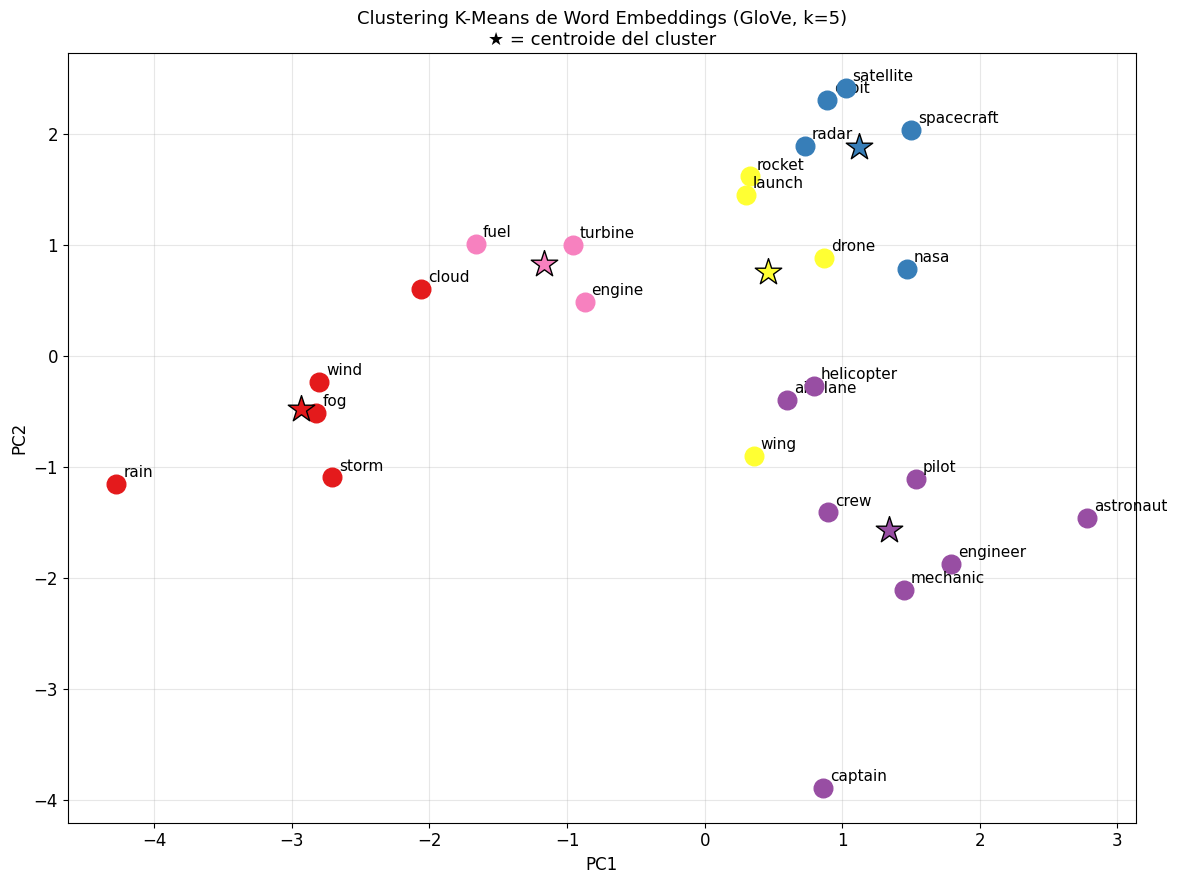


Clusters encontrados:
  Cluster 0: ['storm', 'fog', 'wind', 'cloud', 'rain']
  Cluster 1: ['spacecraft', 'radar', 'orbit', 'satellite', 'nasa']
  Cluster 2: ['airplane', 'helicopter', 'pilot', 'captain', 'engineer', 'mechanic', 'crew', 'astronaut']
  Cluster 3: ['rocket', 'drone', 'wing', 'launch']
  Cluster 4: ['engine', 'fuel', 'turbine']


In [24]:
from sklearn.cluster import KMeans

palabras_cluster = [
    'airplane', 'helicopter', 'rocket', 'drone', 'spacecraft',  # aeronaves
    'pilot', 'captain', 'engineer', 'mechanic', 'crew',          # personal
    'engine', 'fuel', 'turbine', 'wing', 'radar',                # sistemas
    'storm', 'fog', 'wind', 'cloud', 'rain',                     # meteorología
    'orbit', 'satellite', 'launch', 'nasa', 'astronaut',         # espacio
]

words_ok = [w for w in palabras_cluster if w in glove]
vecs_cluster = np.array([glove[w] for w in words_ok])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(vecs_cluster)

# Reducir a 2D con PCA para visualizar
pca_c = PCA(n_components=2, random_state=42)
coords_c = pca_c.fit_transform(vecs_cluster)

fig, ax = plt.subplots(figsize=(12, 9))
colors_k = plt.cm.Set1(np.linspace(0, 0.8, 5))
for i, (word, label) in enumerate(zip(words_ok, labels)):
    x, y = coords_c[i]
    ax.scatter(x, y, color=colors_k[label], s=180, zorder=3)
    ax.annotate(word, (x, y), textcoords='offset points', xytext=(5, 5), fontsize=11)

# Centroides
centroides_2d = pca_c.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroides_2d):
    ax.scatter(cx, cy, color=colors_k[i], s=400, marker='*', zorder=4,
               edgecolors='black', linewidths=1)

ax.set_title('Clustering K-Means de Word Embeddings (GloVe, k=5)\n★ = centroide del cluster', fontsize=13)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar los clusters
print('\nClusters encontrados:')
for k in range(5):
    miembros = [words_ok[i] for i, l in enumerate(labels) if l == k]
    print(f'  Cluster {k}: {miembros}')

### 6.3 Guardar y cargar modelos Word2Vec

In [25]:
# Guardar el modelo entrenado
modelo_w2v.save('word2vec_aviacion.model')
print('Modelo guardado en word2vec_aviacion.model')

# También se puede guardar solo los vectores en formato Word2Vec binario
modelo_w2v.wv.save_word2vec_format('word2vec_aviacion.bin', binary=True)
print('Vectores guardados en formato binario')

# Cargar el modelo completo
modelo_cargado = Word2Vec.load('word2vec_aviacion.model')
print(f'\nModelo recargado. Vocabulario: {len(modelo_cargado.wv)} palabras')
print(f'Prueba: similitud(avión, piloto) = {modelo_cargado.wv.similarity("avión", "piloto"):.4f}')

Modelo guardado en word2vec_aviacion.model
Vectores guardados en formato binario

Modelo recargado. Vocabulario: 149 palabras
Prueba: similitud(avión, piloto) = 0.8083


### 6.4 Límites del enfoque: OOV y actualización del vocabulario

In [26]:
# OOV (Out-Of-Vocabulary): palabras no vistas en entrenamiento
palabras_oov = ['supersónico', 'hipersónico', 'vertiport', 'eVTOL']

print('Gestión de palabras OOV (Out-Of-Vocabulary):')
print()
for palabra in palabras_oov:
    en_vocab = palabra in modelo_w2v.wv
    print(f'  "{palabra}" en vocabulario Word2Vec propio: {en_vocab}')

print()
print('Estrategias para OOV:')
print('  1. Word2Vec: no puede manejar OOV (requiere reentrenamiento)')
print('  2. FastText: descompone en n-gramas → puede representar palabras nuevas')
print('  3. BPE/Subword (BERT, GPT): tokenización a nivel de subpalabra')
print('  4. Continual learning: reentrenar incrementalmente con nuevos datos')

Gestión de palabras OOV (Out-Of-Vocabulary):

  "supersónico" en vocabulario Word2Vec propio: False
  "hipersónico" en vocabulario Word2Vec propio: False
  "vertiport" en vocabulario Word2Vec propio: False
  "eVTOL" en vocabulario Word2Vec propio: False

Estrategias para OOV:
  1. Word2Vec: no puede manejar OOV (requiere reentrenamiento)
  2. FastText: descompone en n-gramas → puede representar palabras nuevas
  3. BPE/Subword (BERT, GPT): tokenización a nivel de subpalabra
  4. Continual learning: reentrenar incrementalmente con nuevos datos


In [27]:
# Actualización incremental de Word2Vec (añadir nuevas frases)
nuevas_frases = [
    "el eVTOL es un vehículo aéreo eléctrico de despegue vertical",
    "el vertiport es la infraestructura para eVTOL",
]
nuevos_tokens = [frase.lower().split() for frase in nuevas_frases]

# Actualizar vocabulario y continuar entrenamiento
modelo_w2v.build_vocab(nuevos_tokens, update=True)
modelo_w2v.train(nuevos_tokens, total_examples=len(nuevos_tokens), epochs=50)

print(f'Vocabulario actualizado: {len(modelo_w2v.wv)} palabras')
for p in ['eVTOL', 'vertiport']:
    if p in modelo_w2v.wv:
        sim = modelo_w2v.wv.most_similar(p, topn=3)
        print(f'Palabras cercanas a "{p}": {sim}')

Vocabulario actualizado: 156 palabras
Palabras cercanas a "vertiport": [('espera', 0.9267477989196777), ('impide', 0.9238601326942444), ('niebla', 0.9234113097190857)]


## Resumen y conclusiones

| Método | Dimensión | Semántica | Entrenamiento | Uso recomendado |
|--------|-----------|-----------|---------------|-----------------|
| **One-Hot** | N (vocab) | ❌ | Ninguno | Clasificación simple, línea base |
| **Word2Vec** | 50–300 | ✅ | Propio / pre-entrenado | NLP clásico, corpus específico |
| **GloVe** | 50–300 | ✅ | Pre-entrenado | NLP general, analogías |
| **FastText** | 50–300 | ✅+ | Propio / pre-entrenado | Morfología, OOV, idiomas ricos |
| **BERT/GPT** | 768+ | ✅✅ | Pre-entrenado + fine-tuning | SOTA en tareas NLP |

### Conceptos clave
- **Hipótesis distribucional**: las palabras que aparecen en los mismos contextos tienen significados similares
- **Similitud coseno**: mide el ángulo entre vectores, independiente de la magnitud
- **Analogías vectoriales**: las relaciones semánticas se reflejan como transformaciones geométricas en el espacio
- **Sentence Embeddings**: promediar word vectors es una aproximación rápida; modelos como Sentence-BERT son mucho mejores
- **OOV**: Word2Vec no maneja palabras nuevas; FastText y los modelos de subpalabra sí lo hacen

### Próximos pasos
- **FastText**: extensión de Word2Vec con subpalabras
- **Sentence-BERT**: embeddings contextuales de frases
- **Transfer Learning**: fine-tuning de BERT/GPT para tareas específicas de aviación